In this exercise, you will further analyze the Wage data set considered
throughout this chapter.


(a) Perform polynomial regression to predict wage using age. Use
cross-validation to select the optimal degree d for the polynomial. What degree was chosen, and how does this compare to
the results of hypothesis testing using ANOVA? Make a plot of
the resulting polynomial fit to the data.


In [8]:
import pandas as pd
df = pd.read_csv("https://raw.githubusercontent.com/JWarmenhoven/ISLR-python/master/Notebooks/Data/Wage.csv")


Optimal polynomial degree = 8


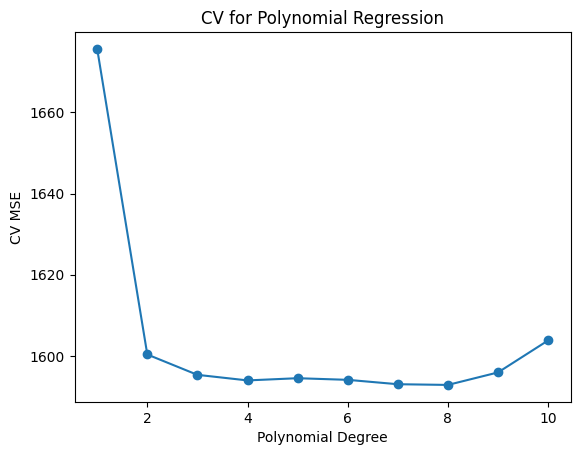

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


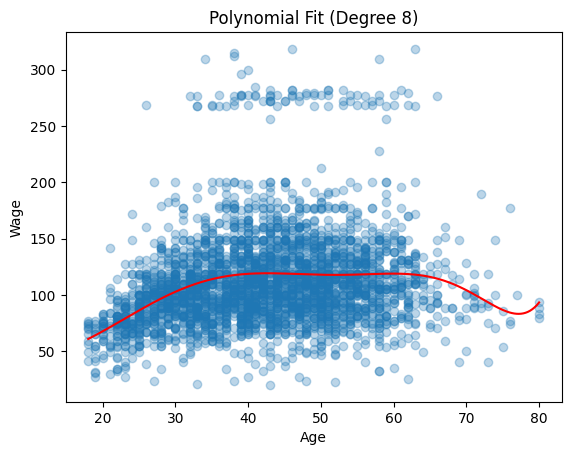

In [9]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt

X = df[['age']]
y = df['wage']

degrees = range(1, 11)
cv_errors = []

for d in degrees:
    model = Pipeline([
        ('poly', PolynomialFeatures(degree=d)),
        ('linreg', LinearRegression())
    ])
    mse = -cross_val_score(model, X, y, cv=10, scoring='neg_mean_squared_error').mean()
    cv_errors.append(mse)

best_degree = np.argmin(cv_errors) + 1
print("Optimal polynomial degree =", best_degree)

plt.plot(degrees, cv_errors, marker='o')
plt.xlabel("Polynomial Degree")
plt.ylabel("CV MSE")
plt.title("CV for Polynomial Regression")
plt.show()

model = Pipeline([
    ('poly', PolynomialFeatures(degree=best_degree)),
    ('linreg', LinearRegression())
])
model.fit(X, y)

age_grid = np.linspace(X.min(), X.max(), 200).reshape(-1, 1)
pred = model.predict(age_grid)

plt.scatter(df['age'], df['wage'], alpha=0.3)
plt.plot(age_grid, pred, color='red')
plt.xlabel("Age")
plt.ylabel("Wage")
plt.title(f"Polynomial Fit (Degree {best_degree})")
plt.show()


(b) Fit a step function to predict wage using age, and perform crossvalidation to choose the optimal number of cuts. Make a plot of
the fit obtained.

Optimal number of segments = 8


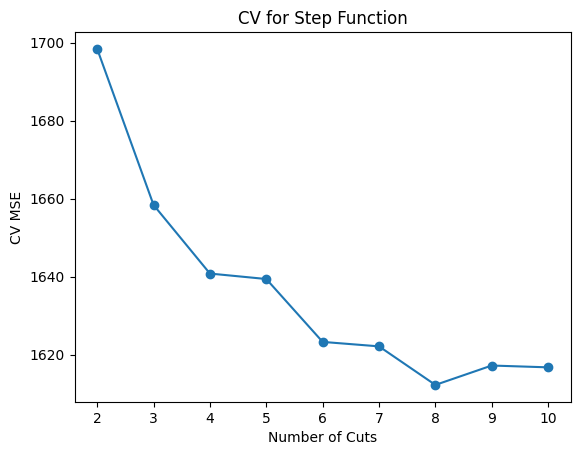

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KBinsDiscretizer was fitted with feature names
  warnings.warn(


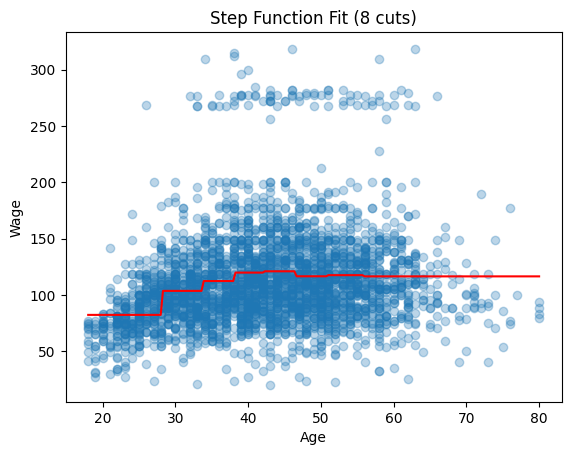

In [10]:
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.model_selection import cross_val_score

cuts = range(2, 11)
cv_errors = []

for k in cuts:
    est = KBinsDiscretizer(n_bins=k, encode='onehot', strategy='quantile')
    X_step = est.fit_transform(X)

    lin = LinearRegression()
    mse = -cross_val_score(lin, X_step, y, cv=10, scoring='neg_mean_squared_error').mean()
    cv_errors.append(mse)

best_k = np.argmin(cv_errors) + 2
print("Optimal number of segments =", best_k)

plt.plot(cuts, cv_errors, marker='o')
plt.xlabel("Number of Cuts")
plt.ylabel("CV MSE")
plt.title("CV for Step Function")
plt.show()

est = KBinsDiscretizer(n_bins=best_k, encode='onehot', strategy='quantile')
X_step = est.fit_transform(X)
lin = LinearRegression().fit(X_step, y)

bin_edges = est.bin_edges_[0]
age_bin = np.digitize(age_grid, bin_edges[1:-1])
pred_step = lin.predict(est.transform(age_grid))

plt.scatter(df['age'], df['wage'], alpha=0.3)
plt.plot(age_grid, pred_step, color='red')
plt.xlabel("Age")
plt.ylabel("Wage")
plt.title(f"Step Function Fit ({best_k} cuts)")
plt.show()
